In [121]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [122]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [123]:
df = pd.read_csv("loan_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()
print(df.columns)
df.columns=df.columns.str.strip()
print(df.columns)


Dataset loaded successfully!
Shape: (4269, 13)
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [124]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


In [125]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True) * 100)

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
Duplicate rows: 0
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


. EDA

Rows: 4269
Columns: 13


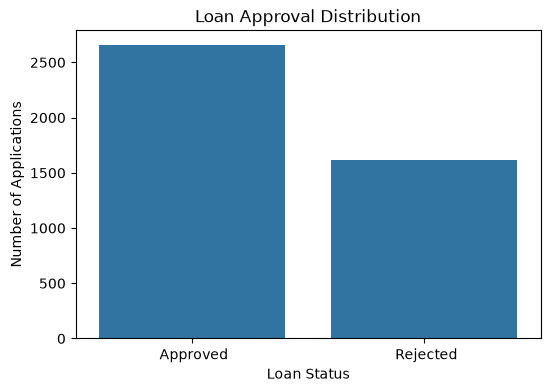

In [126]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()


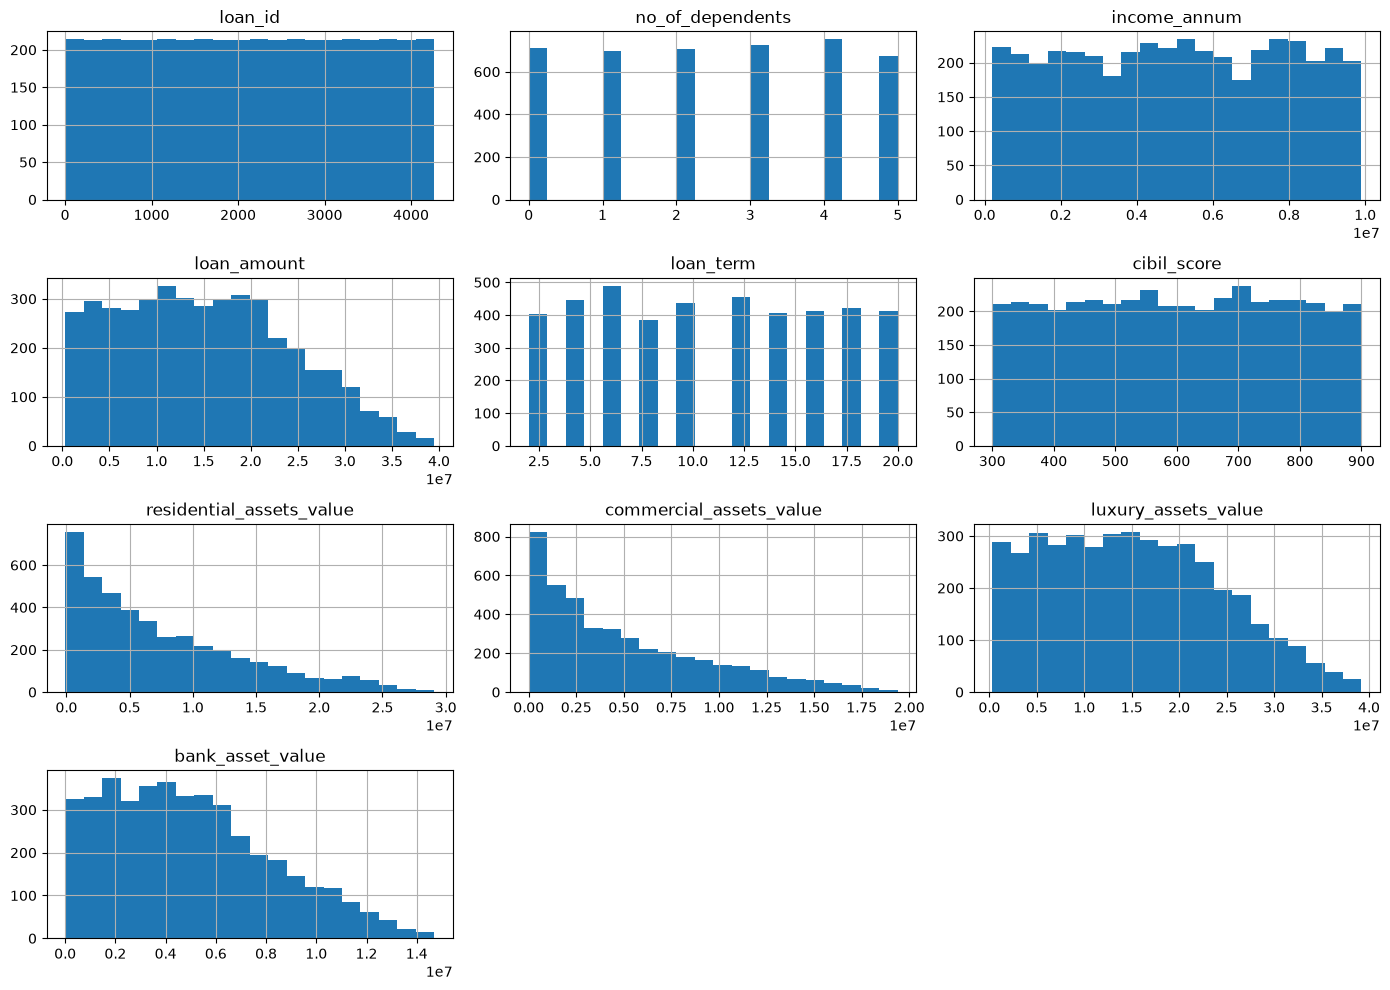

In [127]:
df.select_dtypes(include=np.number).hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

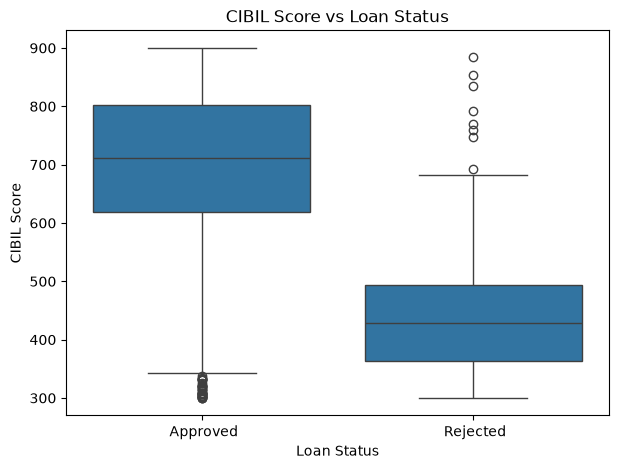

In [128]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="cibil_score"
)

plt.title("CIBIL Score vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")
plt.show()

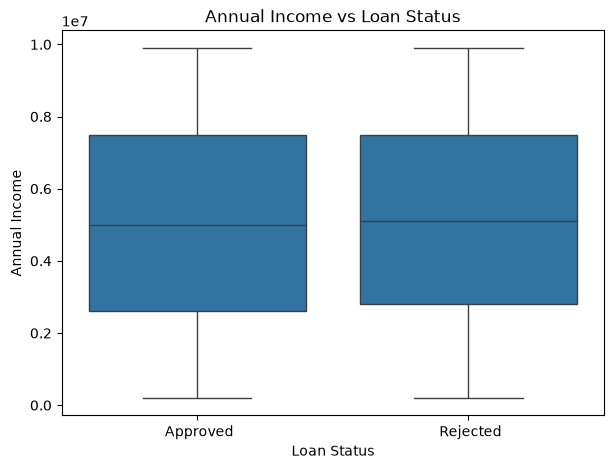

In [129]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="income_annum"
)

plt.title("Annual Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
plt.show()

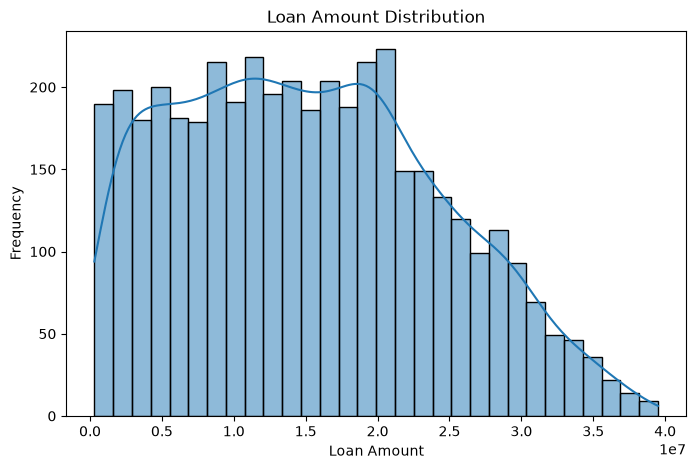

In [130]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="loan_amount",
    bins=30,
    kde=True

)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

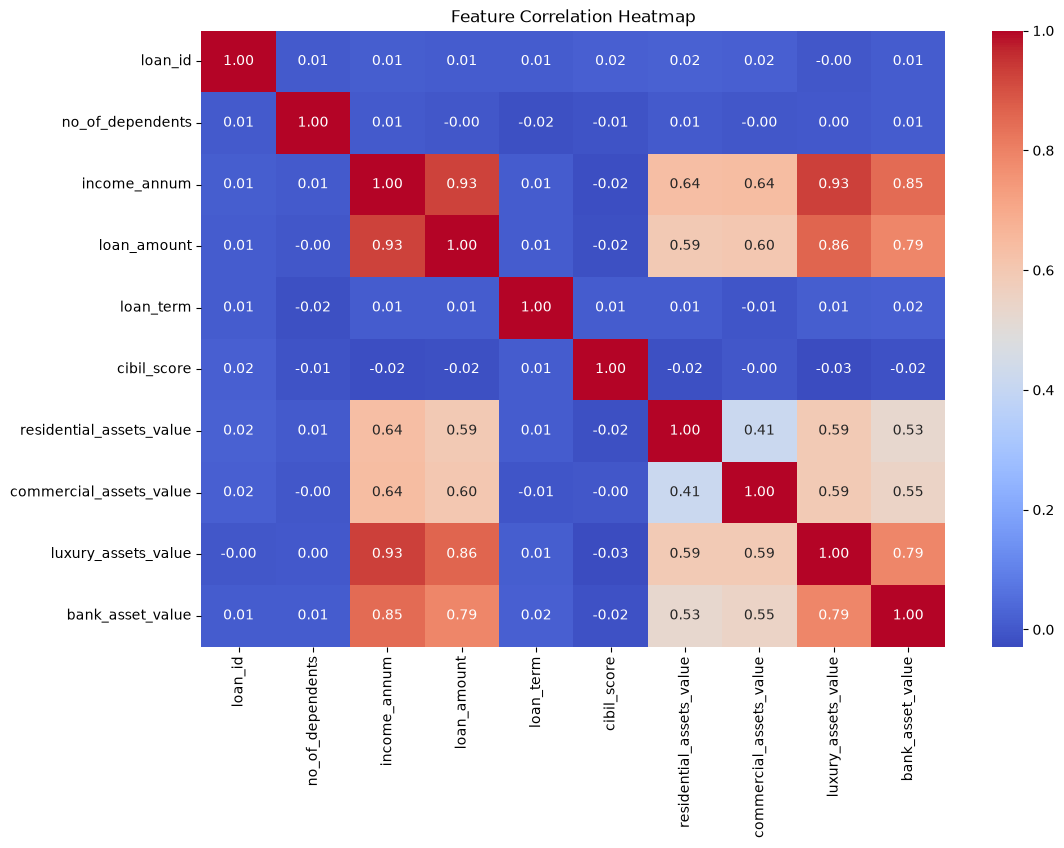

In [131]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

Data Preprocessing

In [132]:
df = df.drop(columns=["loan_id"])
print(df.columns)
print(df.dtypes)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='str')
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object


In [133]:
print("Education:")
print(df["education"].unique())

print("\nSelf Employed:")
print(df["self_employed"].unique())

print("\nLoan Status:")
print(df["loan_status"].unique())

Education:
<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str

Self Employed:
<StringArray>
[' No', ' Yes']
Length: 2, dtype: str

Loan Status:
<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [134]:
df["education"] = df["education"].map({
    " Graduate": 1,
    " Not Graduate": 0,
    "Graduate": 1,
    "Not Graduate": 0
})
df["self_employed"] = df["self_employed"].map({
    " Yes": 1,
    " No": 0,
    "Yes": 1,
    "No": 0
})
print(df[["education", "self_employed"]].head())
print(df.isnull().sum())
numeric_columns = df.select_dtypes(
    include=np.number
).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)
print(df.isnull().sum())

   education  self_employed
0          1              0
1          0              1
2          1              0
3          1              0
4          0              1
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [135]:
print("Final shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Final shape: (4269, 12)

Data types:
no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object

Missing values:
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

First 5 rows:


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Classification Target

In [136]:
print(df["loan_status"].unique())
print(df["loan_status"].value_counts())
df["loan_status"] = (
    df["loan_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "approved": 1,
        "rejected": 0
    })
)


<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [137]:
print(df["loan_status"].unique())
print(df["loan_status"].value_counts())

[1 0]
loan_status
1    2656
0    1613
Name: count, dtype: int64


In [138]:
if df["loan_status"].isnull().any():
    raise ValueError(
        "loan_status contains values that could not "
        "be converted to 0/1."
    )

print("Target conversion successful!")

Target conversion successful!


In [139]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny values:")
print(y.value_counts())

X shape: (4269, 11)
y shape: (4269,)

X columns:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

y values:
loan_status
1    2656
0    1613
Name: count, dtype: int64


In [140]:
y = y.to_numpy()
print(y.dtype)
print(y.shape)

int64
(4269,)


Train/Test Split

We'll use 80% training / 20% testing

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3415, 11)
X_test : (854, 11)
y_train: (3415,)
y_test : (854,)


In [142]:
print("Training distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts())

Training distribution:
1    2125
0    1290
Name: count, dtype: int64

Testing distribution:
1    531
0    323
Name: count, dtype: int64


In [143]:
scaler_cls = StandardScaler()

X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

print("Training mean:", X_train_scaled.mean())
print("Training std :", X_train_scaled.std())

Training mean: -7.849733404510624e-18
Training std : 1.0


In [144]:
#Convert to PyTorch Tensors and target
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)
y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).reshape(-1, 1)
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_test :", X_test_tensor.shape)
print("y_test :", y_test_tensor.shape)

print("\nData types:")
print(X_train_tensor.dtype)
print(y_train_tensor.dtype)

X_train: torch.Size([3415, 11])
y_train: torch.Size([3415, 1])
X_test : torch.Size([854, 11])
y_test : torch.Size([854, 1])

Data types:
torch.float32
torch.float32


In [145]:
print("NaN in X_train:", torch.isnan(X_train_tensor).any().item())
print("NaN in y_train:", torch.isnan(y_train_tensor).any().item())

print("Inf in X_train:", torch.isinf(X_train_tensor).any().item())
print("Inf in y_train:", torch.isinf(y_train_tensor).any().item())

NaN in X_train: False
NaN in y_train: False
Inf in X_train: False
Inf in y_train: False


DataLoader

In [146]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [147]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([64, 11])
y batch shape: torch.Size([64, 1])


Build Classification ANN

In [148]:
class LoanClassifierANN(nn.Module):

    def __init__(self, input_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [149]:
#create model
model_cls = LoanClassifierANN(
    input_features=X_train_tensor.shape[1]
)
print(model_cls)

#loss function and optimizer
criterion_cls = nn.BCEWithLogitsLoss()
optimizer_cls = torch.optim.Adam(
    model_cls.parameters(),
    lr=0.001
)

LoanClassifierANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


Train on GPU

In [150]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
model_cls = model_cls.to(device)

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


Training loop

In [151]:
epochs = 100

train_losses = []

for epoch in range(epochs):

    model_cls.train()

    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Move data to GPU/CPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer_cls.zero_grad()

        # Forward pass
        predictions = model_cls(X_batch)

        # Calculate loss
        loss = criterion_cls(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_cls.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    train_losses.append(average_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {average_loss:.4f}"
        )

Epoch [10/100] Loss: 0.1425
Epoch [20/100] Loss: 0.0901
Epoch [30/100] Loss: 0.0531
Epoch [40/100] Loss: 0.0385
Epoch [50/100] Loss: 0.0338
Epoch [60/100] Loss: 0.0262
Epoch [70/100] Loss: 0.0384
Epoch [80/100] Loss: 0.0227
Epoch [90/100] Loss: 0.0143
Epoch [100/100] Loss: 0.0126


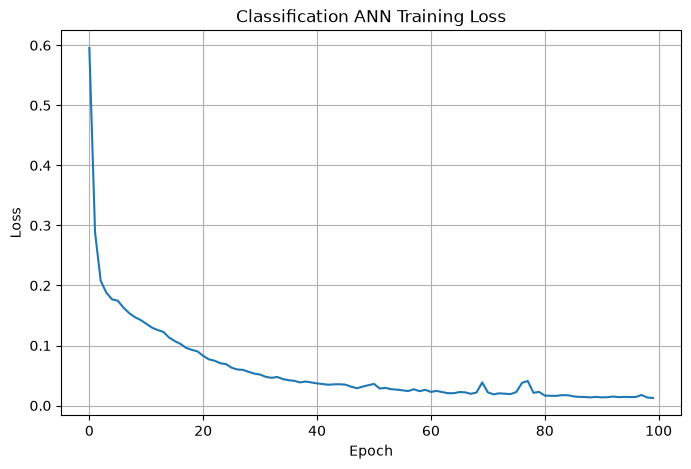

In [152]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses
)

plt.title("Classification ANN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.show()

Evaluate

In [153]:
model_cls.eval()

all_predictions = []
all_actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model_cls(X_batch)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        # Convert probability to 0/1
        predictions = (
            probabilities >= 0.5
        ).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_actual.extend(
            y_batch.numpy().flatten()
        )

In [154]:
y_pred = np.array(all_predictions)
y_true = np.array(all_actual)

Classification Metrics

In [155]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)
precision = precision_score(
    y_true,
    y_pred
)

print("Precision:", precision)
recall = recall_score(
    y_true,
    y_pred
)

print("Recall:", recall)
f1 = f1_score(
    y_true,
    y_pred
)

print("F1 Score:", f1)
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Rejected", "Approved"]
    )
)

Accuracy: 0.968384074941452
Precision: 0.9666666666666667
Recall: 0.9830508474576272
F1 Score: 0.9747899159663865
              precision    recall  f1-score   support

    Rejected       0.97      0.94      0.96       323
    Approved       0.97      0.98      0.97       531

    accuracy                           0.97       854
   macro avg       0.97      0.96      0.97       854
weighted avg       0.97      0.97      0.97       854



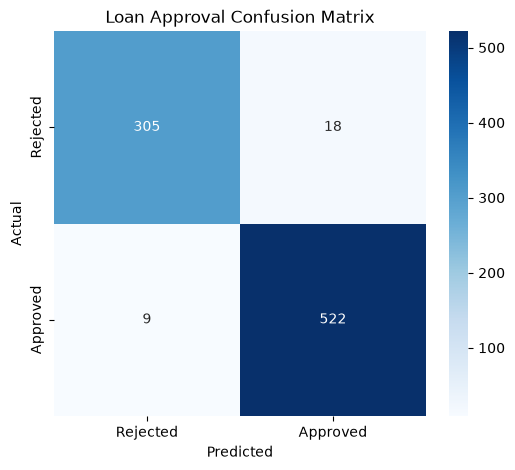

In [156]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval Confusion Matrix")

plt.show()

In [157]:
def predict_approval_probability(
    model,
    X_data,
    scaler,
    device
):

    model.eval()

    # Scale input
    X_scaled = scaler.transform(X_data)

    # Convert to tensor
    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        logits = model(X_tensor)

        probabilities = torch.sigmoid(
            logits
        )

    return probabilities.cpu().numpy().flatten()

In [158]:
sample_customers = X_test.iloc[:5]
probabilities = predict_approval_probability(
    model_cls,
    sample_customers,
    scaler_cls,
    device
)

In [159]:
for i, probability in enumerate(probabilities):

    prediction = (
        "Approved"
        if probability >= 0.5
        else "Rejected"
    )

    print(
        f"Customer {i + 1}: "
        f"{probability * 100:.2f}% → {prediction}"
    )

Customer 1: 99.88% → Approved
Customer 2: 0.00% → Rejected
Customer 3: 0.00% → Rejected
Customer 4: 100.00% → Approved
Customer 5: 99.99% → Approved


In [160]:
print("Device:", device)
print("Final training loss:", train_losses[-1])
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Device: cuda
Final training loss: 0.012569769359456754
Accuracy: 0.968384074941452
Precision: 0.9666666666666667
Recall: 0.9830508474576272
F1: 0.9747899159663865


Filter Approved Customers

In [161]:
approved_df = df[df["loan_status"] == 1].copy()

print("Total customers:", len(df))
print("Approved customers:", len(approved_df))
print("Rejected customers:", len(df) - len(approved_df))
approved_df.head()
print(approved_df["loan_status"].value_counts())



Total customers: 4269
Approved customers: 2656
Rejected customers: 1613
loan_status
1    2656
Name: count, dtype: int64


Prepare Loan Amount Target

In [162]:
y_reg = approved_df["loan_amount"]
X_reg = approved_df.drop(
    columns=["loan_amount", "loan_status"]
)
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

print("\nFeatures:")
print(X_reg.columns.tolist())

print("\nTarget:")
print(y_reg.head())

X_reg shape: (2656, 10)
y_reg shape: (2656,)

Features:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Target:
0     29900000
6     33000000
8      2200000
10    11200000
13    31500000
Name: loan_amount, dtype: int64


Train/Test Split

Use an 80/20 split

In [163]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_reg_train:", X_reg_train.shape)
print("X_reg_test :", X_reg_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test :", y_reg_test.shape)

X_reg_train: (2124, 10)
X_reg_test : (532, 10)
y_reg_train: (2124,)
y_reg_test : (532,)


In [164]:
scaler_reg = StandardScaler()

X_reg_train_scaled = scaler_reg.fit_transform(
    X_reg_train
)

X_reg_test_scaled = scaler_reg.transform(
    X_reg_test
)

# Convert pandas Series to NumPy arrays
y_reg_train_np = y_reg_train.to_numpy()
y_reg_test_np = y_reg_test.to_numpy()

# Create target scaler
y_reg_scaler = StandardScaler()

# Scale regression target
y_reg_train_scaled = y_reg_scaler.fit_transform(
    y_reg_train_np.reshape(-1, 1)
)

y_reg_test_scaled = y_reg_scaler.transform(
    y_reg_test_np.reshape(-1, 1)
)

print("Target scaling successful!")
print("Train target shape:", y_reg_train_scaled.shape)
print("Test target shape :", y_reg_test_scaled.shape)

Target scaling successful!
Train target shape: (2124, 1)
Test target shape : (532, 1)


In [165]:
print("X mean:", X_reg_train_scaled.mean())
print("X std :", X_reg_train_scaled.std())

print("y mean:", y_reg_train_scaled.mean())
print("y std :", y_reg_train_scaled.std())

X mean: -2.4587990149890472e-17
X std : 1.0
y mean: 9.366853390434466e-17
y std : 1.0000000000000002


Tensors + DataLoader

In [166]:
X_reg_train_tensor = torch.tensor(
    X_reg_train_scaled,
    dtype=torch.float32
)

X_reg_test_tensor = torch.tensor(
    X_reg_test_scaled,
    dtype=torch.float32
)
y_reg_train_tensor = torch.tensor(
    y_reg_train_scaled,
    dtype=torch.float32
)

y_reg_test_tensor = torch.tensor(
    y_reg_test_scaled,
    dtype=torch.float32
)
print("X train:", X_reg_train_tensor.shape)
print("y train:", y_reg_train_tensor.shape)

print("X test :", X_reg_test_tensor.shape)
print("y test :", y_reg_test_tensor.shape)

X train: torch.Size([2124, 10])
y train: torch.Size([2124, 1])
X test : torch.Size([532, 10])
y test : torch.Size([532, 1])


In [167]:
#create dataset and dataloader
reg_train_dataset = TensorDataset(
    X_reg_train_tensor,
    y_reg_train_tensor
)

reg_test_dataset = TensorDataset(
    X_reg_test_tensor,
    y_reg_test_tensor
)
reg_train_loader = DataLoader(
    reg_train_dataset,
    batch_size=64,
    shuffle=True
)

reg_test_loader = DataLoader(
    reg_test_dataset,
    batch_size=64,
    shuffle=False

)
X_batch, y_batch = next(iter(reg_train_loader))

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([64, 10])
y batch: torch.Size([64, 1])


Build Regression ANN

In [168]:
class LoanRegressorANN(nn.Module):

    def __init__(self, input_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [169]:
#create loss function and optimizer
model_reg = LoanRegressorANN(
    input_features=X_reg_train_tensor.shape[1]
)

print(model_reg)
criterion_reg = nn.MSELoss()
optimizer_reg = torch.optim.Adam(
    model_reg.parameters(),
    lr=0.001
)

LoanRegressorANN(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


Train on GPU and loop

In [170]:
model_reg = model_reg.to(device)

print("Regression model device:", device)
epochs_reg = 100

reg_train_losses = []

for epoch in range(epochs_reg):

    model_reg.train()

    epoch_loss = 0.0

    for X_batch, y_batch in reg_train_loader:

        # Move data to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer_reg.zero_grad()

        # Forward pass
        predictions = model_reg(X_batch)

        # Calculate loss
        loss = criterion_reg(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_reg.step()

        epoch_loss += loss.item()

    average_loss = (
        epoch_loss / len(reg_train_loader)
    )

    reg_train_losses.append(
        average_loss
    )

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs_reg}] "
            f"Loss: {average_loss:.4f}"
        )

Regression model device: cuda


Epoch [10/100] Loss: 0.1261
Epoch [20/100] Loss: 0.1139
Epoch [30/100] Loss: 0.1070
Epoch [40/100] Loss: 0.1003
Epoch [50/100] Loss: 0.0917
Epoch [60/100] Loss: 0.0844
Epoch [70/100] Loss: 0.0798
Epoch [80/100] Loss: 0.0715
Epoch [90/100] Loss: 0.0673
Epoch [100/100] Loss: 0.0639


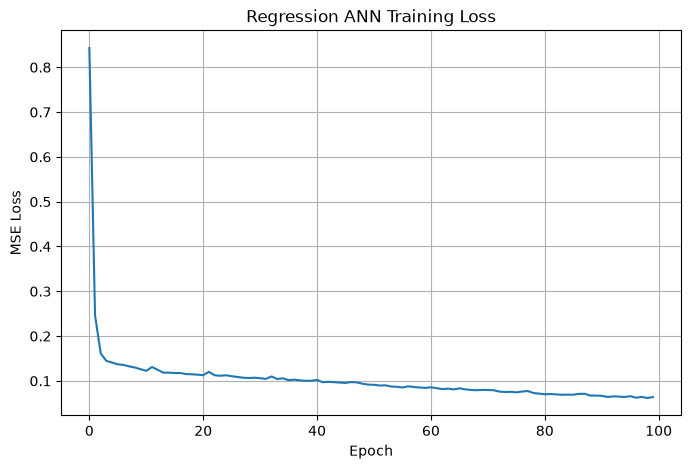

In [171]:
plt.figure(figsize=(8, 5))

plt.plot(
    reg_train_losses
)

plt.title("Regression ANN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()

plt.show()

Evaluate Regression ANN

In [172]:
model_reg.eval()

reg_predictions_scaled = []

with torch.no_grad():

    for X_batch, _ in reg_test_loader:

        X_batch = X_batch.to(device)

        predictions = model_reg(
            X_batch
        )

        reg_predictions_scaled.extend(
            predictions.cpu().numpy().flatten()
        )

In [173]:
reg_predictions_scaled = np.array(
    reg_predictions_scaled
)
reg_predictions = y_reg_scaler.inverse_transform(
    reg_predictions_scaled.reshape(-1, 1)
).flatten()
reg_actual = y_reg_test

Calculate Metric

In [174]:
mae_reg = mean_absolute_error(
    reg_actual,
    reg_predictions
)

print("MAE:", mae_reg)
mse_reg = mean_squared_error(
    reg_actual,
    reg_predictions
)

print("MSE:", mse_reg)
rmse_reg = np.sqrt(mse_reg)

print("RMSE:", rmse_reg)
r2_reg = r2_score(
    reg_actual,
    reg_predictions
)

print("R²:", r2_reg)


MAE: 2745835.75
MSE: 14216300855296.0
RMSE: 3770451.0148384105
R²: 0.8346012234687805


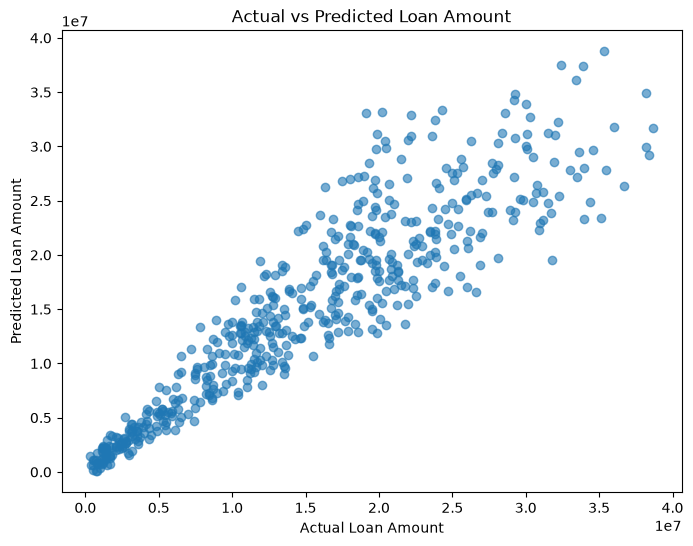

In [175]:
plt.figure(figsize=(8, 6))

plt.scatter(
    reg_actual,
    reg_predictions,
    alpha=0.6
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")

plt.show()

In [176]:
def predict_loan_amount(
    model,
    X_data,
    feature_scaler,
    target_scaler,
    device
):

    model.eval()

    # Scale input
    X_scaled = feature_scaler.transform(
        X_data
    )

    # Convert to tensor
    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)

    # Prediction
    with torch.no_grad():

        predictions_scaled = model(
            X_tensor
        )

    # Move back to CPU
    predictions_scaled = (
        predictions_scaled
        .cpu()
        .numpy()
    )

    # Reverse target scaling
    predictions = target_scaler.inverse_transform(
        predictions_scaled
    )

    return predictions.flatten()

In [177]:
sample_approved = X_reg_test.iloc[:5]

predicted_amounts = predict_loan_amount(
    model_reg,
    sample_approved,
    scaler_reg,
    y_reg_scaler,
    device
)
for i, amount in enumerate(predicted_amounts):

    print(
        f"Customer {i + 1}: "
        f"Predicted Loan Amount = {amount:,.2f}"
    )

Customer 1: Predicted Loan Amount = 10,691,490.00
Customer 2: Predicted Loan Amount = 20,229,818.00
Customer 3: Predicted Loan Amount = 6,847,692.00
Customer 4: Predicted Loan Amount = 12,202,865.00
Customer 5: Predicted Loan Amount = 19,544,786.00


In [178]:
print("Device:", device)
print("Final regression loss:", reg_train_losses[-1])
print("MAE:", mae_reg)
print("MSE:", mse_reg)
print("RMSE:", rmse_reg)
print("R²:", r2_reg)

Device: cuda
Final regression loss: 0.06387592895942576
MAE: 2745835.75
MSE: 14216300855296.0
RMSE: 3770451.0148384105
R²: 0.8346012234687805


In [179]:
print(X.columns.tolist())
def create_customer_input():
    
    no_of_dependents = int(
        input("Number of Dependents: ")
    )
    
    education = input(
        "Education (Graduate/Not Graduate): "
    ).strip().lower()
    
    if education == "graduate":
        education = 1
    elif education == "not graduate":
        education = 0
    else:
        raise ValueError(
            "Education must be Graduate or Not Graduate."
        )
    
    self_employed = input(
        "Self Employed (Yes/No): "
    ).strip().lower()
    
    if self_employed == "yes":
        self_employed = 1
    elif self_employed == "no":
        self_employed = 0
    else:
        raise ValueError(
            "Self Employed must be Yes or No."
        )
    
    income_annum = float(
        input("Annual Income: ")
    )
    
    loan_amount = float(
        input("Requested Loan Amount: ")
    )
    
    loan_term = int(
        input("Loan Term (years): ")
    )
    
    cibil_score = float(
        input("CIBIL Score: ")
    )
    
    residential_assets_value = float(
        input("Residential Assets Value: ")
    )
    
    commercial_assets_value = float(
        input("Commercial Assets Value: ")
    )
    
    luxury_assets_value = float(
        input("Luxury Assets Value: ")
    )
    
    bank_asset_value = float(
        input("Bank Asset Value: ")
    )
    
    customer = pd.DataFrame([{
        "no_of_dependents": no_of_dependents,
        "education": education,
        "self_employed": self_employed,
        "income_annum": income_annum,
        "loan_amount": loan_amount,
        "loan_term": loan_term,
        "cibil_score": cibil_score,
        "residential_assets_value": residential_assets_value,
        "commercial_assets_value": commercial_assets_value,
        "luxury_assets_value": luxury_assets_value,
        "bank_asset_value": bank_asset_value
    }])
    
    return customer

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [180]:
def predict_loan_approval(
    model,
    customer,
    scaler,
    device
):
    
    model.eval()
    
    # Scale customer data
    X_scaled = scaler.transform(customer)
    
    # Convert to tensor
    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)
    
    with torch.no_grad():
        
        logits = model(X_tensor)
        
        probability = torch.sigmoid(
            logits
        ).item()
    
    prediction = (
        1 if probability >= 0.5 else 0
    )
    
    return prediction, probability

In [181]:
def predict_requested_loan_amount(
    model,
    customer,
    feature_scaler,
    target_scaler,
    device
):
    
    model.eval()
    
    # Remove target column
    regression_input = customer.drop(
        columns=["loan_amount"]
    )
    
    # Scale features
    X_scaled = feature_scaler.transform(
        regression_input
    )
    
    # Convert to tensor
    X_tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32
    ).to(device)
    
    with torch.no_grad():
        
        prediction_scaled = model(
            X_tensor
        )
    
    # Return to original loan amount scale
    prediction = target_scaler.inverse_transform(
        prediction_scaled.cpu().numpy()
    )
    
    return prediction.item()

In [182]:
def loan_decision_system(
    customer,
    classification_model,
    regression_model,
    classification_scaler,
    regression_feature_scaler,
    regression_target_scaler,
    device
):
    
    # -----------------------------
    # Classification
    # -----------------------------
    
    approval, probability = predict_loan_approval(
        classification_model,
        customer,
        classification_scaler,
        device
    )
    
    print("\n" + "=" * 45)
    print("        LOAN DECISION SYSTEM")
    print("=" * 45)
    
    print(
        f"Approval Probability: "
        f"{probability * 100:.2f}%"
    )
    
    if approval == 0:
        
        print("Decision: REJECTED")
        print(
            "Recommendation: "
            "Application does not meet the model's "
            "approval threshold."
        )
        
        return
    
    # -----------------------------
    # Regression
    # -----------------------------
    
    predicted_amount = predict_requested_loan_amount(
        regression_model,
        customer,
        regression_feature_scaler,
        regression_target_scaler,
        device
    )
    
    print("Decision: APPROVED")
    
    print(
        f"Predicted Loan Amount: "
        f"{predicted_amount:,.2f}"
    )
    
    print(
        "Recommendation: "
        "Application is predicted as approved."
    )
    
    print("=" * 45)

save and load model

In [183]:
torch.save(
    model_cls.state_dict(),
    "loan_classifier.pth"
)
torch.save(
    model_reg.state_dict(),
    "loan_regressor.pth"
)
import os

print(
    "Classification model saved:",
    os.path.exists("loan_classifier.pth")
)

print(
    "Regression model saved:",
    os.path.exists("loan_regressor.pth")
)


Classification model saved: True
Regression model saved: True


In [184]:
import joblib

joblib.dump(
    scaler_cls,
    "classification_scaler.pkl"
)

joblib.dump(
    scaler_reg,
    "regression_feature_scaler.pkl"
)

joblib.dump(
    y_reg_scaler,
    "regression_target_scaler.pkl"
)

['regression_target_scaler.pkl']

In [188]:
example_customer = X_test.iloc[[0]].copy()

print(example_customer)

      no_of_dependents  education  self_employed  income_annum  loan_amount  \
2856                 3          0              1       8300000     31400000   

      loan_term  cibil_score  residential_assets_value  \
2856          6          674                   1000000   

      commercial_assets_value  luxury_assets_value  bank_asset_value  
2856                  1600000             17200000           6100000  


In [186]:
loan_decision_system(
    example_customer,
    model_cls,
    model_reg,
    scaler_cls,
    scaler_reg,
    y_reg_scaler,
    device
)


        LOAN DECISION SYSTEM
Approval Probability: 99.88%
Decision: APPROVED
Predicted Loan Amount: 23,249,588.00
Recommendation: Application is predicted as approved.


In [187]:
for i in range(5):
    
    customer = X_test.iloc[[i]].copy()
    
    print(f"\nCustomer {i + 1}")
    
    loan_decision_system(
        customer,
        model_cls,
        model_reg,
        scaler_cls,
        scaler_reg,
        y_reg_scaler,
        device
    )


Customer 1

        LOAN DECISION SYSTEM
Approval Probability: 99.88%
Decision: APPROVED
Predicted Loan Amount: 23,249,588.00
Recommendation: Application is predicted as approved.

Customer 2

        LOAN DECISION SYSTEM
Approval Probability: 0.00%
Decision: REJECTED
Recommendation: Application does not meet the model's approval threshold.

Customer 3

        LOAN DECISION SYSTEM
Approval Probability: 0.00%
Decision: REJECTED
Recommendation: Application does not meet the model's approval threshold.

Customer 4

        LOAN DECISION SYSTEM
Approval Probability: 100.00%
Decision: APPROVED
Predicted Loan Amount: 10,396,037.00
Recommendation: Application is predicted as approved.

Customer 5

        LOAN DECISION SYSTEM
Approval Probability: 99.99%
Decision: APPROVED
Predicted Loan Amount: 3,657,586.00
Recommendation: Application is predicted as approved.
